In [1]:
from ultralytics import YOLO

In [2]:
model_200_l = YOLO(model="runs/2026-06-01 16:23:06 220 l/weights/best.pt")

In [ ]:
#Run batched inference on a list of images
results = model_200_l.predict(source="sample1", imgsz=640, classes=[0,1], show=True, iou=0.5, save=True)  # return a list of Results objects



image 1/105 /home/ai_vison/Desktop/PPE/model_finetune/person/sample1/helmet_jacket_05079.jpg: 640x640 1 half_person, 5.0ms
image 2/105 /home/ai_vison/Desktop/PPE/model_finetune/person/sample1/helmet_jacket_05081.jpg: 640x640 4 half_persons, 2 persons, 4.3ms
image 3/105 /home/ai_vison/Desktop/PPE/model_finetune/person/sample1/helmet_jacket_05145.jpg: 640x640 2 half_persons, 4.5ms
image 4/105 /home/ai_vison/Desktop/PPE/model_finetune/person/sample1/helmet_jacket_05146.jpg: 640x640 1 half_person, 4.3ms
image 5/105 /home/ai_vison/Desktop/PPE/model_finetune/person/sample1/helmet_jacket_05147.jpg: 640x640 1 person, 4.3ms
image 6/105 /home/ai_vison/Desktop/PPE/model_finetune/person/sample1/helmet_jacket_05148.jpg: 640x640 2 half_persons, 4.4ms
image 7/105 /home/ai_vison/Desktop/PPE/model_finetune/person/sample1/helmet_jacket_05150.jpg: 640x640 4 half_persons, 3 persons, 4.5ms
image 8/105 /home/ai_vison/Desktop/PPE/model_finetune/person/sample1/helmet_jacket_05151.jpg: 640x640 3 persons, 4.5m

: 

In [3]:
inf_img = model_200_l.predict(source="sample1/helmet_jacket_06384.jpg", imgsz=640, classes=[0,1], save=True, show=True, conf=0.60)  # return a list of Results objects


QFontDatabase: Cannot find font directory /home/ai_vison/miniconda3/envs/ppe/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ai_vison/miniconda3/envs/ppe/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ai_vison/miniconda3/envs/ppe/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ai_vison/miniconda3/envs/ppe/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot fi


image 1/1 /home/ai_vison/Desktop/PPE/model_finetune/person/sample1/helmet_jacket_06384.jpg: 640x640 1 half_person, 2 persons, 4.7ms
Speed: 0.9ms preprocess, 4.7ms inference, 22.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /home/ai_vison/Desktop/PPE/model_finetune/person/runs/detect/predict-2


In [4]:
print(inf_img[0])

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'half_person', 1: 'person'}
obb: None
orig_img: array([[[ 18,  20,  20],
        [ 15,  17,  17],
        [ 18,  20,  20],
        ...,
        [ 27,  28,  24],
        [ 24,  25,  21],
        [ 21,  22,  18]],

       [[ 16,  18,  18],
        [ 15,  17,  17],
        [ 12,  14,  14],
        ...,
        [ 27,  28,  24],
        [ 24,  25,  21],
        [ 22,  23,  19]],

       [[ 20,  22,  22],
        [ 30,  32,  32],
        [ 30,  32,  32],
        ...,
        [ 26,  27,  23],
        [ 23,  24,  20],
        [ 21,  22,  18]],

       ...,

       [[169, 194, 204],
        [178, 203, 213],
        [175, 197, 208],
        ...,
        [196, 201, 200],
        [206, 211, 210],
        [200, 205, 204]],

       [[163, 187, 199],
        [157, 181, 193],
        [164, 186, 198],
        ...,
        [186, 191, 190],
        [227, 232, 2

In [7]:
for x in range(1):
    print(inf_img[0].boxes[x])

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1.], device='cuda:0')
conf: tensor([0.8687], device='cuda:0')
data: tensor([[307.7226, 315.4075, 640.0000, 640.0000,   0.8687,   1.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([1, 6])
xywh: tensor([[473.8613, 477.7038, 332.2774, 324.5925]], device='cuda:0')
xywhn: tensor([[0.7404, 0.7464, 0.5192, 0.5072]], device='cuda:0')
xyxy: tensor([[307.7226, 315.4075, 640.0000, 640.0000]], device='cuda:0')
xyxyn: tensor([[0.4808, 0.4928, 1.0000, 1.0000]], device='cuda:0')


In [55]:
# for x in range(5):
#     print(inf_img[0].boxes[x].conf)

In [56]:
# inf_img[0].boxes[2].xyxy

In [57]:
import torch
import torchvision

# Your first box in xyxy format
box1 = torch.tensor([[ 13.1572, 213.5504, 335.6323, 639.7269]], device='cuda:0')

# Example second box to compare against
box2 = torch.tensor([[ 13.2525, 211.4725, 319.5779, 639.6135]], device='cuda:0') 

def calculate_iou(box1, box2):
    # box_iou compares all boxes in box1 to all boxes in box2
    iou = torchvision.ops.box_iou(box1, box2)
    return iou

iou = calculate_iou(box1, box2)
print("IoU:", iou.item())

IoU: 0.9452886581420898


In [58]:
def is_overlap(box1, box2):
    iou = calculate_iou(box1, box2)
    print(iou)
    return iou > 0.7

def non_max_suppression(boxes):
    # Sort boxes by confidence in descending order
    try: 
        boxes = sorted(boxes, key=lambda x: x.conf, reverse=True)
        keep = []

        while boxes:
            # Take the box with highest confidence
            current = boxes.pop(0)
            keep.append(current)

            # Remove boxes that overlap too much with current box
            boxes = [box for box in boxes if
                        not is_overlap(current.xyxy, box.xyxy)]

        return keep
    except Exception as e:
        print(f"An error occurred during non-max suppression: {e}")
        return []

In [59]:
keep = non_max_suppression(inf_img[0].boxes)

tensor([[0.1053]], device='cuda:0')
tensor([[0.0383]], device='cuda:0')
tensor([[0.0683]], device='cuda:0')


In [60]:
len(keep)

3

In [61]:
for k in keep:
    print(k.conf)

tensor([0.8687], device='cuda:0')
tensor([0.8201], device='cuda:0')
tensor([0.7143], device='cuda:0')


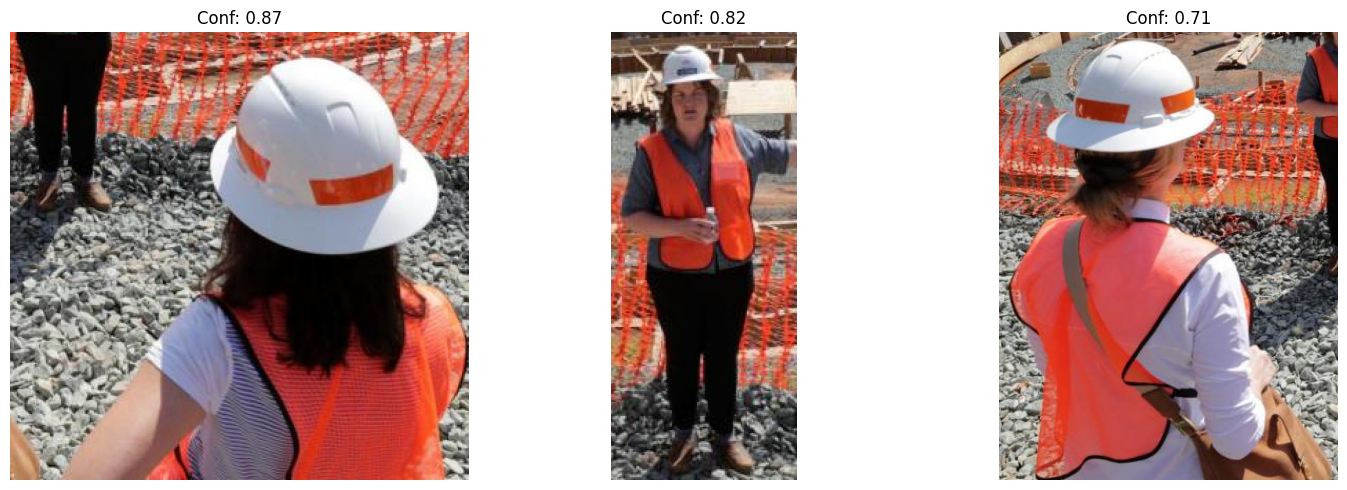

In [ ]:
# # import cv2
# import matplotlib.pyplot as plt

# # The original image is stored in BGR format by default
# orig_image = inf_img[0].orig_img
# # Convert to RGB since matplotlib expects RGB colors for visualization
# orig_image_rgb = cv2.cvtColor(orig_image, cv2.COLOR_BGR2RGB)

# # Create a sequence of subplots
# fig, axes = plt.subplots(1, len(keep), figsize=(15, 5))

# # Handle the case where there is only 1 box kept (axes won't be a list)
# if len(keep) == 1:
#     axes = [axes]

# for i, k in enumerate(keep):
#     # Extract coordinates and convert them to integers
#     x1, y1, x2, y2 = map(int, k.xyxy[0].tolist())
    
#     # Extract out the cropped section using NumPy slicing: image[y_start:y_end, x_start:x_end]
#     cropped_img = orig_image_rgb[y1:y2, x1:x2]
    
#     # Plot the extracted image crop
#     axes[i].imshow(cropped_img)
#     axes[i].set_title(f"Conf: {k.conf.item():.2f}")
#     axes[i].axis('off')

# plt.tight_layout()
# plt.show()


In [ ]:
import os
import cv2

# Create a directory to save the extracted images
save_dir = "extracted_objects"
os.makedirs(save_dir, exist_ok=True)

for i, k in enumerate(keep):
    # Extract coordinates and convert them to integers
    x1, y1, x2, y2 = map(int, k.xyxy[0].tolist())
    
    # Crop from the original BGR image
    cropped_bgr = inf_img[0].orig_img[y1:y2, x1:x2]
    
    # Create a filename with the index and confidence score
    filename = os.path.join(save_dir, f"extracted_{i}_conf_{k.conf.item():.2f}.jpg")
    
    # Save the image to disk
    cv2.imwrite(filename, cropped_bgr)
    print(f"Saved: {filename}")

Saved: extracted_objects/extracted_0_conf_0.87.jpg
Saved: extracted_objects/extracted_1_conf_0.82.jpg
Saved: extracted_objects/extracted_2_conf_0.71.jpg


: 